In [7]:
# Đường dẫn dataset trên Kaggle theo cấu trúc bạn đang có
DATASET_PATH = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"   # ← Đã sửa

print("Dataset path:", DATASET_PATH)
print("Số thư mục lớp:", len(os.listdir(DATASET_PATH)))
print("Một số lớp mẫu:", os.listdir(DATASET_PATH)[:10])  # In thử để kiểm tra

Dataset path: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
Số thư mục lớp: 38
Một số lớp mẫu: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot']


In [8]:
classes = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
print("Số lượng lớp:", len(classes))
print("Một số lớp mẫu:", classes[:10])

Số lượng lớp: 38
Một số lớp mẫu: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


In [11]:
batch_size = 32  # Giảm thêm để an toàn

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(200, 200),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(200, 200),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print("✅ Train samples:", train_generator.samples)
print("✅ Validation samples:", val_generator.samples)
print("Số lớp:", train_generator.num_classes)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
✅ Train samples: 43456
✅ Validation samples: 10849
Số lớp: 38


In [12]:
# Xây dựng mô hình CNN
model = tf.keras.models.Sequential([
    # Layer 1
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    # Layer 2
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    
    # Layer 3
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    
    # Layer 4
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    
    # Layer 5
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    
    # Fully Connected Layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(classes), activation='softmax')
])

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780639974.897473      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780639974.903422      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 198, 198, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 97, 97, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,502 (916.02 KB)

 Trainable params: 234,022 (914.15 KB)

 Non-trainable params: 480 (1.88 KB)

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Callbacks
checkpoint = ModelCheckpoint('best_plant_disease_model.h5', 
                             monitor='val_accuracy', 
                             save_best_only=True, 
                             mode='max',
                             verbose=1)

early_stop = EarlyStopping(monitor='val_accuracy', 
                           patience=5, 
                           restore_best_weights=True,
                           verbose=1)

# Training
EPOCHS = 15

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/15


I0000 00:00:1780640074.875928     190 service.cc:152] XLA service 0x7e37e00967c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780640074.875981     190 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780640074.875988     190 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780640075.491361     190 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-05 06:14:37.568575: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 06:14:37.708334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


   1/1358 ━━━━━━━━━━━━━━━━━━━━ 3:29:45 9s/step - accuracy: 0.0312 - loss: 6.3515

I0000 00:00:1780640081.414809     190 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.3888 - loss: 2.4027
Epoch 1: val_accuracy improved from None to 0.67192, saving model to best_plant_disease_model.h5


...


Epoch 2: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 540s 397ms/step - accuracy: 0.6750 - loss: 1.1108 - val_accuracy: 0.7562 - val_loss: 0.8419
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.7295 - loss: 0.9171
Epoch 3: val_accuracy improved from 0.75618 to 0.77277, saving model to best_plant_disease_model.h5



Epoch 3: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 560s 413ms/step - accuracy: 0.7423 - loss: 0.8703 - val_accuracy: 0.7728 - val_loss: 0.8084
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.7770 - loss: 0.7609
Epoch 4: val_accuracy improved from 0.77277 to 0.81444, saving model to best_plant_disease_model.h5



Epoch 4: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 533s 393ms/step - accuracy: 0.7832 - loss: 0.7379 - val_accuracy: 0.8144 - val_loss: 0.7055
Epoch 5/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.8024 - loss: 0.6716
Epoch 5: val_accuracy did not improve from 0.81444
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 563s 415ms/step - accuracy: 0.8096 - loss: 0.6490 - val_accuracy: 0.7826 - val_loss: 0.7347
Epoch 6/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.8247 - loss: 0.5992
Epoch 6: val_accuracy improved from 0.81444 to 0.87482, saving model to best_plant_disease_model.h5



Epoch 6: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 538s 396ms/step - accuracy: 0.8259 - loss: 0.5967 - val_accuracy: 0.8748 - val_loss: 0.4169
Epoch 7/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8368 - loss: 0.5554
Epoch 7: val_accuracy did not improve from 0.87482
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 528s 389ms/step - accuracy: 0.8394 - loss: 0.5489 - val_accuracy: 0.7940 - val_loss: 0.8942
Epoch 8/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.8461 - loss: 0.5310
Epoch 8: val_accuracy did not improve from 0.87482
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 527s 388ms/step - accuracy: 0.8469 - loss: 0.5280 - val_accuracy: 0.8513 - val_loss: 0.5492
Epoch 9/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.8586 - loss: 0.4915
Epoch 9: val_accuracy did not improve from 0.87482
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 556s 409ms/step - accuracy: 0.8589 - loss: 0.4943 - val_accuracy: 0.8082 - val_loss: 0.6111
Epoch 10/15
1358/1358 


Epoch 11: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 562s 414ms/step - accuracy: 0.8719 - loss: 0.4499 - val_accuracy: 0.9360 - val_loss: 0.2086
Epoch 12/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.8757 - loss: 0.4335
Epoch 12: val_accuracy did not improve from 0.93603
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 563s 415ms/step - accuracy: 0.8781 - loss: 0.4288 - val_accuracy: 0.8962 - val_loss: 0.3421
Epoch 13/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.8825 - loss: 0.4083
Epoch 13: val_accuracy did not improve from 0.93603
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 569s 419ms/step - accuracy: 0.8838 - loss: 0.4030 - val_accuracy: 0.9062 - val_loss: 0.2910
Epoch 14/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.8881 - loss: 0.3943
Epoch 14: val_accuracy did not improve from 0.93603
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 545s 401ms/step - accuracy: 0.8853 - loss: 0.3991 - val_accuracy: 0.9026 - val_loss: 0.3431
Epoch 15/15
135

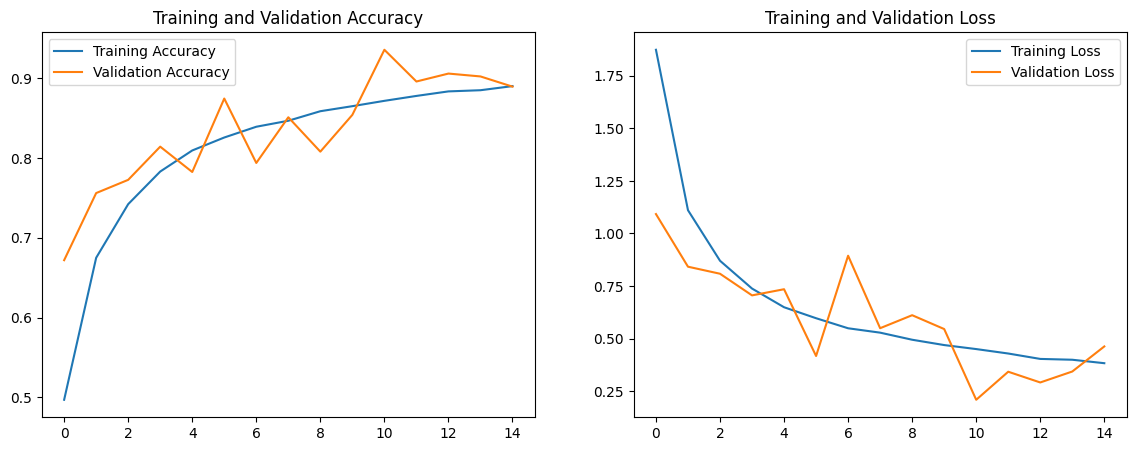

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [15]:
os.makedirs("tflite_models", exist_ok=True)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = "tflite_models/plant_disease_model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("✅ Xuất TFLite thành công tại:", tflite_path)

INFO:tensorflow:Assets written to: /tmp/tmpsomrvn5s/assets


INFO:tensorflow:Assets written to: /tmp/tmpsomrvn5s/assets


Saved artifact at '/tmp/tmpsomrvn5s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 200, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  138782919517456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138782919518992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138782919520912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138782919518608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138782919518416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138782919519952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138782919520528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138782919520720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138782919522448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138782919522640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1387829195218

W0000 00:00:1780648600.413931      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780648600.413975      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1780648600.431155      58 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
